In [1]:
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torchvision.models.video import R3D_18_Weights
import torchvision

import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from IPython.display import clear_output
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as functional
import random

Load the Data

In [2]:
# Pair each video with its alignment file
video_align_pairs = []

# Files should be in the format:
# data
# ├── subset1
# │   ├── s1
# │   └── align
# ├── subset2
# │   ├── s2
# │   └── align
# . . .  
# └── subset10

for subset in range(10):
    base_path = "data"
    subset_path = f"subset{subset+1}"
    video_dir = os.path.join(base_path, subset_path, f"s{subset+1}")
    align_dir = os.path.join(base_path, subset_path, "align")
    video_files = [f for f in os.listdir(video_dir) if f.endswith('.mpg')]
    
    for vf in video_files:
        base = os.path.splitext(vf)[0]
        align_path = os.path.join(align_dir, base + ".align")
        video_path = os.path.join(video_dir, vf)
        if os.path.exists(align_path):
            video_align_pairs.append((video_path, align_path))

print(f"Found {len(video_align_pairs)} video-align pairs.")

# First split: train vs (val+test)
train_pairs, valtest_pairs = train_test_split(
    video_align_pairs, test_size=0.4, random_state=42
)

# Second split: validation vs test (split valtest in half)
val_pairs, test_pairs = train_test_split(
    valtest_pairs, test_size=0.5, random_state=42
)

print(f"Train set size: {len(train_pairs)}")
print(f"Validation set size: {len(val_pairs)}")
print(f"Test set size: {len(test_pairs)}")



Found 10000 video-align pairs.
Train set size: 6000
Validation set size: 2000
Test set size: 2000


Pre-Processing dataset, extract each frames

In [3]:
# Preprocessing transform
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((112, 112)),
    T.ToTensor(),
    T.Normalize([0.43216, 0.394666, 0.37645], [0.22803, 0.22145, 0.216989])
])

def preprocess_frames(frames):
    processed = [transform(frame) for frame in frames]
    video_tensor = torch.stack(processed)  # (T, C, H, W)
    video_tensor = video_tensor.permute(1, 0, 2, 3)  # (C, T, H, W)
    return video_tensor.unsqueeze(0)  # (1, C, T, H, W)

def parse_align_file(align_path):
    alignments = []
    with open(align_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                start, end, word = parts
                alignments.append((int(start), int(end), word))
    return alignments

def extract_word_frames(video_path, alignments):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    word_frames = []
    for start, end, word in alignments:
        start_idx = int(start / 1000)
        end_idx = int(end / 1000)
        word_seq = frames[start_idx:end_idx]
        if word_seq:
            word_frames.append((word, word_seq))
    return word_frames

Encoder:

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
# def preprocess_pairs(pairs):
#     new_pairs = []
#     for video_path, align_path in tqdm(pairs):
#         alignments = parse_align_file(align_path)
#         word_frames = extract_word_frames(video_path, alignments)
#         for word, frames in word_frames:
#             video_tensor = preprocess_frames(frames).to(device)
#             new_pairs.append((word, video_tensor))
#     return new_pairs

In [6]:
# all_words = []
# for _, align_path in train_pairs:
#     alignments = parse_align_file(align_path)
#     for _, _, word in alignments:
#         all_words.append(word)

# train_pairs = preprocess_pairs(train_pairs)
# val_pairs = preprocess_pairs(val_pairs)
# test_pairs = preprocess_pairs(test_pairs)

In [7]:
class VideoVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=53):  # set num_classes to your vocab size
        super().__init__()
        base = torchvision.models.video.r3d_18(weights=R3D_18_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.encoder_out_dim = 512
        self.fc_mu = nn.Linear(self.encoder_out_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.encoder_out_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, self.encoder_out_dim),
            nn.ReLU(),
            nn.Linear(self.encoder_out_dim, self.encoder_out_dim)
        )
        self.classifier = nn.Linear(latent_dim, num_classes)  # classification head

    def encode(self, x):
        x = self.encoder(x)
        x = x.flatten(1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        logits = self.classifier(mu)  # use mu for classification
        return recon, mu, logvar, logits

Training loop (Slower one)

Epoch 10: Loss=0.8203, Recon=0.0014, KL=0.1661


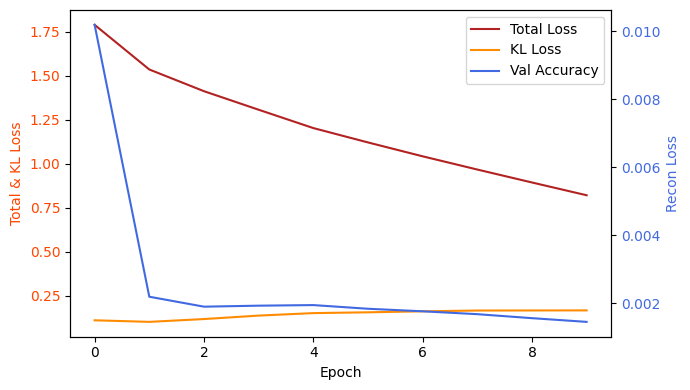

VideoVAE(
  (encoder): Sequential(
    (0): BasicStem(
      (0): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (conv2): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (relu): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv1): Sequential(
          (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), strid

In [8]:
latent_dim = 128
num_epochs = 10
learning_rate = 1e-4
beta = 1.0  # KL loss weight

all_words = []
for _, align_path in train_pairs:
    alignments = parse_align_file(align_path)
    for _, _, word in alignments:
        all_words.append(word)

# Fit LabelEncoder on all words
le = LabelEncoder()
le.fit(all_words)
num_classes = len(le.classes_)
print(f"Number of unique classes: {num_classes}")

#There are 53 classes in the dataset

vae = VideoVAE(latent_dim=latent_dim, num_classes=num_classes).to(device)
optimizer = optim.Adam(vae.parameters(), lr=learning_rate)
vae.train()

all_loss = []
all_recon = []
all_kl = []

# --- Training Loop ---
for epoch in range(num_epochs):

    total_loss = 0
    total_recon = 0
    total_kl = 0
    count = 0
    
    curr_batch_size = 1500
    curr_batch = random.sample(train_pairs, curr_batch_size)

    for video_path, align_path in tqdm(curr_batch, desc=f"Epoch {epoch+1}/{num_epochs}"):
        alignments = parse_align_file(align_path)
        word_frames = extract_word_frames(video_path, alignments)
        for word, frames in word_frames:
            video_tensor = preprocess_frames(frames).to(device)
            optimizer.zero_grad()
            recon, mu, logvar, logits = vae(video_tensor)
            # Flatten input for reconstruction loss
            target = vae.encoder(video_tensor).flatten(1)
            # Reconstruction loss (MSE between recon and encoder output)
            recon_loss = nn.MSELoss()(recon, target)
            # KL divergence loss
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.size(0)

            word_idx = torch.tensor([le.transform([word])[0]], dtype=torch.long, device=device)
            class_loss = nn.CrossEntropyLoss()(logits, word_idx)

            # Total loss (tune alpha as needed)
            loss = recon_loss + beta * kl_loss + 0.5 * class_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            count += 1
            
    clear_output()
    print(f"Epoch {epoch+1}: Loss={total_loss/count:.4f}, Recon={total_recon/count:.4f}, KL={total_kl/count:.4f}")
    all_loss.append(total_loss/count)
    all_recon.append(total_recon/count)
    all_kl.append(total_kl/count)
    
    # ——— Plot & print ———
    fig, ax1 = plt.subplots(figsize=(7,4))
    
    # ――― primary y-axis: loss ――― #
    ax1.plot(all_loss, color='firebrick', label='Total Loss')
    ax1.plot(all_kl, color='darkorange', label='KL Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Total & KL Loss', color='orangered')
    ax1.tick_params(axis='y', labelcolor='orangered')
    
    # ――― secondary y-axis: accuracy ――― #
    ax2 = ax1.twinx()            # share the same x-axis
    ax2.plot(all_recon, color='royalblue', label='Val Accuracy')
    ax2.set_ylabel('Recon Loss', color='royalblue')
    ax2.tick_params(axis='y', labelcolor='royalblue')
    
    # ――― combined legend ――― #
    lines  = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    
    fig.tight_layout()
    plt.show()

# --- Save the trained model ---
torch.save(vae.state_dict(), "vae_trained.pt")
vae.eval()

BATCH TRAINING:

In [9]:
# def pad_collate(batch):
#     # Remove any samples with empty tensors
#     batch = [(v, w) for v, w in batch if v.shape[2] > 0]
#     if len(batch) == 0:
#         return None, None
#     videos, words = zip(*batch)
#     max_T = max(v.shape[2] for v in videos)
#     padded_videos = []
#     for v in videos:
#         pad_T = max_T - v.shape[2]
#         if pad_T > 0:
#             v = functional.pad(v, (0,0,0,0,0,pad_T))
#         padded_videos.append(v)
#     video_batch = torch.cat(padded_videos, dim=0)
#     return video_batch, list(words)

# class WordVideoDataset(Dataset):
#     def __init__(self, video_align_pairs):
#         self.samples = []
#         for video_path, align_path in video_align_pairs:
#             alignments = parse_align_file(align_path)
#             for start, end, word in alignments:
#                 self.samples.append((video_path, start, end, word))
#     def __len__(self):
#         return len(self.samples)
#     def __getitem__(self, idx):
#         video_path, start, end, word = self.samples[idx]
#         # Extract only the frames for this word on-the-fly
#         alignments = [(start, end, word)]
#         word_frames = extract_word_frames(video_path, alignments)
#         frames = word_frames[0][1]  # get frames for this word
#         video_tensor = preprocess_frames(frames)
#         return video_tensor, word

# train_dataset = WordVideoDataset(train_pairs)
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=8,      # Set your batch size here
#     shuffle=True,
#     pin_memory=True,
#     collate_fn=pad_collate
# )

# latent_dim = 128
# num_epochs = 10
# learning_rate = 1e-4
# beta = 1.0  # KL loss weight

# vae = VideoVAE(latent_dim=latent_dim).to(device)
# optimizer = optim.Adam(vae.parameters(), lr=learning_rate)
# vae.train()

# all_loss = []
# all_recon = []
# all_kl = []

# for epoch in range(num_epochs):
#     total_loss = 0
#     total_recon = 0
#     total_kl = 0
#     count = 0
#     for video_tensor, word in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
#         video_tensor = video_tensor.to(device)
#         optimizer.zero_grad()
#         recon, mu, logvar, _ = vae(video_tensor)
#         target = vae.encoder(video_tensor).flatten(1)
#         recon_loss = nn.MSELoss()(recon, target)
#         kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.size(0)
#         loss = recon_loss + beta * kl_loss
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#         total_recon += recon_loss.item()
#         total_kl += kl_loss.item()
#         count += 1
    
#     clear_output()
#     print(f"Epoch {epoch+1}: Loss={total_loss/count:.4f}, Recon={total_recon/count:.4f}, KL={total_kl/count:.4f}")
#     all_loss.append(total_loss/count)
#     all_recon.append(total_recon/count)
#     all_kl.append(total_kl/count)
    
#     # ——— Plot & print ———
#     fig, ax1 = plt.subplots(figsize=(7,4))
    
#     # ――― primary y-axis: loss ――― #
#     ax1.plot(all_loss, color='firebrick', label='Total Loss')
#     ax1.plot(all_kl, color='darkorange', label='KL Loss')
#     ax1.set_xlabel('Epoch')
#     ax1.set_ylabel('Total & KL Loss', color='orangered')
#     ax1.tick_params(axis='y', labelcolor='orangered')
    
#     # ――― secondary y-axis: accuracy ――― #
#     ax2 = ax1.twinx()            # share the same x-axis
#     ax2.plot(all_recon, color='royalblue', label='Val Accuracy')
#     ax2.set_ylabel('Recon Loss', color='royalblue')
#     ax2.tick_params(axis='y', labelcolor='royalblue')
    
#     # ――― combined legend ――― #
#     lines  = ax1.get_lines() + ax2.get_lines()
#     labels = [l.get_label() for l in lines]
#     ax1.legend(lines, labels, loc='upper right')
    
#     fig.tight_layout()
#     plt.show()

Encode all the dataset

In [10]:
latent_dim = 128
vae = VideoVAE(latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load("vae_trained.pt", map_location=device))
vae.eval()

all_mu = []
all_logvar = []
all_labels = []

for video_path, align_path in tqdm(train_pairs, desc="Encoding training set"):
    alignments = parse_align_file(align_path)
    word_frames = extract_word_frames(video_path, alignments)
    for word, frames in word_frames:
        with torch.no_grad():
            video_tensor = preprocess_frames(frames).to(device)
            mu, logvar = vae.encode(video_tensor)
            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())
            all_labels.append(word)

# Save or use the encoded features
torch.save(all_mu, 'tr_mu.pt')
torch.save(all_logvar, 'tr_logvar.pt')
torch.save(all_labels, 'tr_labels.pt')

Encoding training set: 100%|██████████| 6000/6000 [11:03<00:00,  9.04it/s]


In [11]:
latent_dim = 128
vae = VideoVAE(latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load("vae_trained.pt", map_location=device))
vae.eval()

all_mu = []
all_logvar = []
all_labels = []

for video_path, align_path in tqdm(val_pairs, desc="Encoding validation set"):
    alignments = parse_align_file(align_path)
    word_frames = extract_word_frames(video_path, alignments)
    for word, frames in word_frames:
        with torch.no_grad():
            video_tensor = preprocess_frames(frames).to(device)
            mu, logvar = vae.encode(video_tensor)
            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())
            all_labels.append(word)

# Save or use the encoded features
torch.save(all_mu, 'val_mu.pt')
torch.save(all_logvar, 'val_logvar.pt')
torch.save(all_labels, 'val_labels.pt')

Encoding validation set: 100%|██████████| 2000/2000 [04:03<00:00,  8.22it/s]


In [12]:
latent_dim = 128
vae = VideoVAE(latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load("vae_trained.pt", map_location=device))
vae.eval()

all_mu = []
all_logvar = []
all_labels = []

for video_path, align_path in tqdm(test_pairs, desc="Encoding test data set"):
    alignments = parse_align_file(align_path)
    word_frames = extract_word_frames(video_path, alignments)
    for word, frames in word_frames:
        with torch.no_grad():
            video_tensor = preprocess_frames(frames).to(device)
            mu, logvar = vae.encode(video_tensor)
            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())
            all_labels.append(word)

# Save or use the encoded features
torch.save(all_mu, 'test_mu.pt')
torch.save(all_logvar, 'test_logvar.pt')
torch.save(all_labels, 'test_labels.pt')

Encoding test data set: 100%|██████████| 2000/2000 [03:51<00:00,  8.65it/s]


In [13]:
# Pair each video with its alignment file
outside_test_pairs = []

# Files should be in the format:
# data
# ├── subset1
# │   ├── s1
# │   └── align
# ├── subset2
# │   ├── s2
# │   └── align
# . . .  
# └── subset10

for subset in [11, 12]:
    base_path = "other_tests"
    subset_path = f"subset{subset}"
    video_dir = os.path.join(base_path, subset_path, f"s{subset}")
    align_dir = os.path.join(base_path, subset_path, "align")
    video_files = [f for f in os.listdir(video_dir) if f.endswith('.mpg')]
    
    for vf in video_files:
        base = os.path.splitext(vf)[0]
        align_path = os.path.join(align_dir, base + ".align")
        video_path = os.path.join(video_dir, vf)
        if os.path.exists(align_path):
            outside_test_pairs.append((video_path, align_path))

print(f"Found {len(outside_test_pairs)} video-align pairs.")

Found 2000 video-align pairs.


In [ ]:
latent_dim = 128
vae = VideoVAE(latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load("vae_trained.pt", map_location=device))
vae.eval()

all_mu = []
all_logvar = []
all_labels = []

for video_path, align_path in tqdm(outside_test_pairs, desc="Encoding outside test data set"):
    alignments = parse_align_file(align_path)
    word_frames = extract_word_frames(video_path, alignments)
    for word, frames in word_frames:
        with torch.no_grad():
            video_tensor = preprocess_frames(frames).to(device)
            mu, logvar = vae.encode(video_tensor)
            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())
            all_labels.append(word)

# Save or use the encoded features
torch.save(all_mu, 'outside_test_mu.pt')
torch.save(all_logvar, 'outside_test_logvar.pt')
torch.save(all_labels, 'outside_test_labels.pt')

Encoding outside test data set: 100%|██████████| 2000/2000 [04:17<00:00,  7.77it/s]
